**WorkFlow**:

Data Set

↓

Data PreProcessing

↓

Train Test Split Dataset

↓

SVM Model

↓

Data Evaluation



In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [36]:
dataset = pd.read_csv('loan_dataset.csv')

In [37]:
dataset.shape

(614, 13)

In [38]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [39]:
dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [40]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [41]:
dataset = dataset.dropna()

In [42]:
dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [46]:
dataset.replace({"Loan_Status": {'N': 0, 'Y':1}}, inplace=True)

/tmp/ipykernel_9959/990171595.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({"Loan_Status": {'N': 0, 'Y':1}}, inplace=True)


In [47]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [50]:
dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [52]:
dataset.replace({"Dependents": {'3+' : 4}}, inplace=True)

# or
# dataset = dataset.replace(to_replace='3+', value=4)

In [53]:
dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


<Axes: xlabel='Education', ylabel='count'>

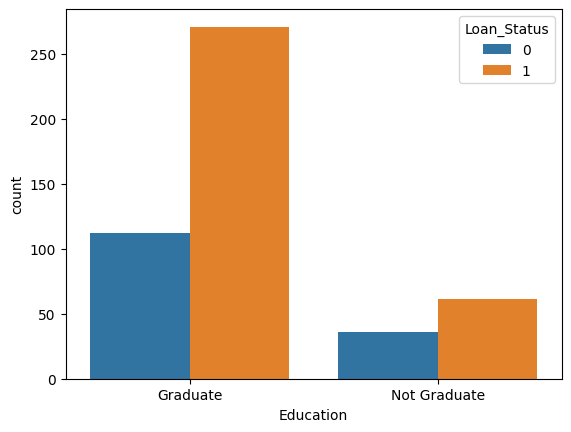

In [54]:
# education vs loan_status

sns.countplot(x='Education', hue='Loan_Status', data=dataset)

<Axes: xlabel='Married', ylabel='count'>

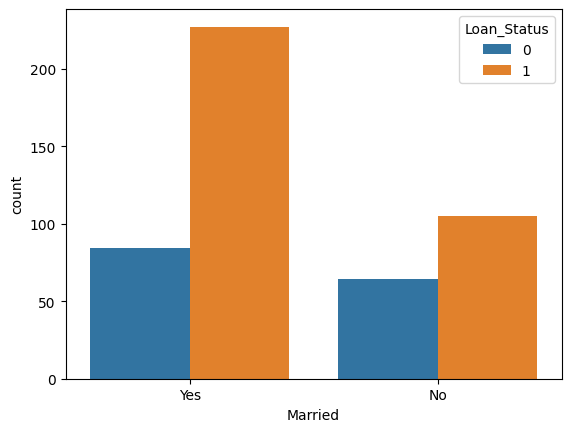

In [55]:
sns.countplot(x='Married', hue='Loan_Status', data=dataset)

<Axes: xlabel='Gender', ylabel='count'>

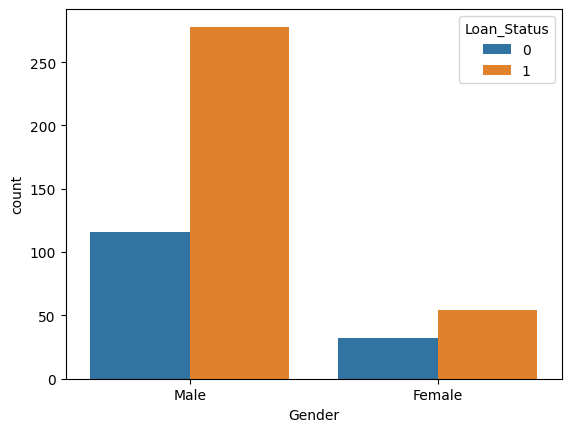

In [56]:
sns.countplot(x='Gender', hue='Loan_Status', data=dataset)

In [57]:
# Convert categorical columns(gender, graduate,married) to numerical value 0,1
dataset.replace({"Married": {'No': 0, 'Yes':1},
                 "Gender": {'Female': 0, 'Male':1},
                 "Self_Employed": {'No': 0, 'Yes':1},
                 "Property_Area": {'Rural': 0, 'Semiurban':1, 'Urban':2},
                 "Education": {'Not Graduate': 0, 'Graduate':1}}, inplace=True)

/tmp/ipykernel_9959/4222304566.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({"Married": {'No': 0, 'Yes':1},


In [58]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [59]:
X = dataset.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
Y = dataset['Loan_Status']

In [60]:
print(X)
print(Y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1         1        1          1          1              0             4583   
2         1        1          0          1              1             3000   
3         1        1          0          0              0             2583   
4         1        0          0          1              0             6000   
5         1        1          2          1              1             5417   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              0             2900   
610       1        1          4          1              0             4106   
611       1        1          1          1              0             8072   
612       1        1          2          1              0             7583   
613       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.1, stratify=Y, random_state=2)

In [62]:
print(X.shape, X_train.shape, X_test.shape)

(480, 11) (432, 11) (48, 11)


In [63]:
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

In [66]:
X_train_prediction = classifier.predict(X_train)
training_accuracy = accuracy_score(X_train_prediction, Y_train)

(training_accuracy)

0.7986111111111112

In [67]:
X_test_prediction = classifier.predict(X_test)
testing_accuracy = accuracy_score(X_test_prediction, Y_test)

(testing_accuracy)

0.8333333333333334

In [68]:
cm_svm = confusion_matrix(Y_test, X_test_prediction)

cm_svm

array([[ 9,  6],
       [ 2, 31]])

Text(95.72222222222221, 0.5, 'Actual')

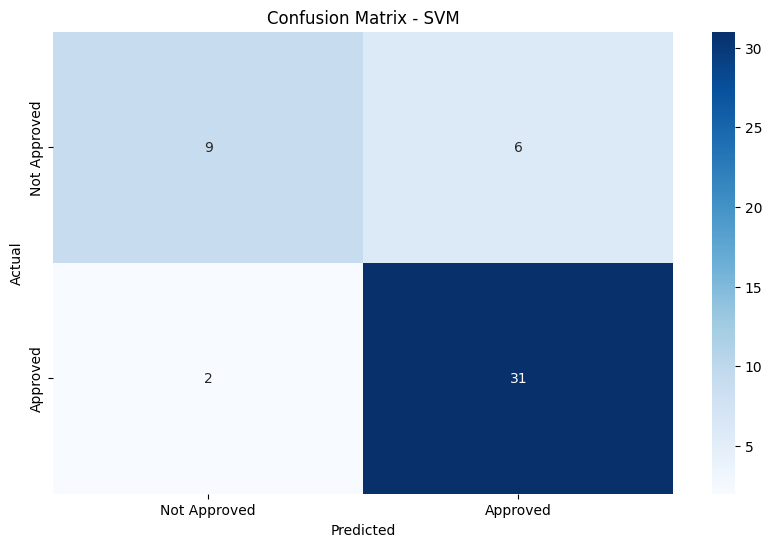

In [70]:
plt.figure(figsize=(10,6))
sns.heatmap(cm_svm, annot=True, cmap='Blues', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')